In [1]:
import os

os.environ['KAGGLE_TOKEN'] = 'KGAT_33fcbd18d1a7242ae24b3cba780f65dd'
os.environ['KAGGLE_USERNAME'] = 'hadimrad'

!pip install kaggle -q

In [2]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset

Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:56<00:00, 18.8MB/s]



In [3]:
import zipfile

with zipfile.ZipFile('plantvillage-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('plantvillage')

print("Done extracting!")

Done extracting!


In [ ]:
import os

dataset_path = 'plantvillage/plantvillage dataset/color'

classes = sorted(os.listdir(dataset_path))
print(f"Total number of classes: {len(classes)}")
print("\nAll classes:")
for i, class_name in enumerate(classes):
    num_images = len(os.listdir(os.path.join(dataset_path, class_name)))
    print(f"{i+1}. {class_name} — {num_images} images")

Total number of classes: 38

All classes:
1. Apple___Apple_scab — 630 images
2. Apple___Black_rot — 621 images
3. Apple___Cedar_apple_rust — 275 images
4. Apple___healthy — 1645 images
5. Blueberry___healthy — 1502 images
6. Cherry_(including_sour)___Powdery_mildew — 1052 images
7. Cherry_(including_sour)___healthy — 854 images
8. Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot — 513 images
9. Corn_(maize)___Common_rust_ — 1192 images
10. Corn_(maize)___Northern_Leaf_Blight — 985 images
11. Corn_(maize)___healthy — 1162 images
12. Grape___Black_rot — 1180 images
13. Grape___Esca_(Black_Measles) — 1383 images
14. Grape___Leaf_blight_(Isariopsis_Leaf_Spot) — 1076 images
15. Grape___healthy — 423 images
16. Orange___Haunglongbing_(Citrus_greening) — 5507 images
17. Peach___Bacterial_spot — 2297 images
18. Peach___healthy — 360 images
19. Pepper,_bell___Bacterial_spot — 997 images
20. Pepper,_bell___healthy — 1478 images
21. Potato___Early_blight — 1000 images
22. Potato___Late_blight —

In [4]:
import numpy as np
import tensorflow as tf
from tensorflow import keras as k
import os
import cv2
from sklearn.model_selection import train_test_split

dataset_path = 'plantvillage/plantvillage dataset/color'
classes = sorted(os.listdir(dataset_path))
num_classes = len(classes)

IMG_SIZE = 128
BATCH_SIZE = 32

print(f"Total classes: {num_classes}")
print("Creating dataset...")

# Create list of all image paths and their labels
image_paths = []
labels = []

for label_index, class_name in enumerate(classes):
    class_path = os.path.join(dataset_path, class_name)
    for image_name in os.listdir(class_path):
        image_paths.append(os.path.join(class_path, image_name))
        labels.append(label_index)

image_paths = np.array(image_paths)
labels = np.array(labels)

print(f"Total images found: {len(image_paths)}")

# Split into train and test — your 80/20 decision
from sklearn.model_selection import train_test_split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths, labels, test_size=0.2, random_state=42, stratify=labels
)

print(f"Training samples: {len(train_paths)}")
print(f"Testing samples: {len(test_paths)}")

Total classes: 38
Creating dataset...
Total images found: 54305
Training samples: 43444
Testing samples: 10861


In [5]:
def load_and_preprocess(path, label):
    # Read image
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    # Resize to your decision: 128x128
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    # Normalize to 0-1: your decision
    #image = image / 255.0
    # One hot encode label: your decision
    label = tf.one_hot(label, num_classes)
    return image, label

# Create training generator
train_dataset = tf.data.Dataset.from_tensor_slices((train_paths, train_labels))
train_dataset = train_dataset.map(load_and_preprocess,
                                   num_parallel_calls=tf.data.AUTOTUNE)
train_dataset = train_dataset.batch(BATCH_SIZE)
train_dataset = train_dataset.prefetch(tf.data.AUTOTUNE)

# Create testing generator
test_dataset = tf.data.Dataset.from_tensor_slices((test_paths, test_labels))
test_dataset = test_dataset.map(load_and_preprocess,
                                 num_parallel_calls=tf.data.AUTOTUNE)
test_dataset = test_dataset.batch(BATCH_SIZE)
test_dataset = test_dataset.prefetch(tf.data.AUTOTUNE)

print("Train and test generators ready!")

Train and test generators ready!


In [6]:
from sklearn.utils.class_weight import compute_class_weight

# Calculate class weights to handle imbalance — your decision
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights calculated!")
print(f"\nSample weights to understand the balance:")
print(f"Potato___healthy (152 images): {class_weight_dict[22]:.2f}")
print(f"Orange___Haunglongbing (5507 images): {class_weight_dict[15]:.2f}")

Class weights calculated!

Sample weights to understand the balance:
Potato___healthy (152 images): 9.37
Orange___Haunglongbing (5507 images): 0.26


In [7]:
# Data augmentation — your decisions: flip, rotation, zoom
data_augmentation = tf.keras.Sequential([
    k.layers.RandomFlip("horizontal"),
    k.layers.RandomRotation(0.2),
    k.layers.RandomZoom(0.2),
], name="data_augmentation")

# Load MobileNetV2 pretrained on ImageNet — your decision
base_model = k.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model — all 154 layers locked
base_model.trainable = False
print(f"Total layers in MobileNetV2: {len(base_model.layers)}")
print(f"Trainable layers after freezing: {len(base_model.trainable_weights)}")

# Build the full model
inputs = k.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = data_augmentation(inputs)
x = k.applications.mobilenet_v2.preprocess_input(x)
x = base_model(x, training=False)  # training=False — critical for BatchNorm
x = k.layers.GlobalAveragePooling2D()(x)
x = k.layers.Dropout(0.2)(x)       # your decision
x = k.layers.Dense(128, activation='relu')(x)  # your decision
x = k.layers.Dropout(0.4)(x)       # your decision
outputs = k.layers.Dense(num_classes, activation='softmax')(x)

model_stage3 = k.Model(inputs, outputs)

# Compile — same optimizer, same loss
model_stage3.compile(
    optimizer=k.optimizers.Adam(learning_rate=0.001),
    loss=k.losses.CategoricalCrossentropy(),
    metrics=[k.metrics.CategoricalAccuracy()]
)

model_stage3.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Total layers in MobileNetV2: 154
Trainable layers after freezing: 0


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [12]:
print("Phase 1: Training with frozen base model...")

history_phase1 = model_stage3.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset,
    class_weight=class_weight_dict
)

Phase 1: Training with frozen base model...
Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 62s 40ms/step - categorical_accuracy: 0.6540 - loss: 1.2149 - val_categorical_accuracy: 0.8498 - val_loss: 0.4932
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 54s 40ms/step - categorical_accuracy: 0.7874 - loss: 0.6757 - val_categorical_accuracy: 0.8663 - val_loss: 0.4303
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - categorical_accuracy: 0.8047 - loss: 0.6128 - val_categorical_accuracy: 0.8651 - val_loss: 0.4240
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 53s 39ms/step - categorical_accuracy: 0.8166 - loss: 0.5715 - val_categorical_accuracy: 0.8818 - val_loss: 0.3707
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 52s 38ms/step - categorical_accuracy: 0.8237 - loss: 0.5458 - val_categorical_accuracy: 0.9046 - val_loss: 0.3064
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 51s 38ms/step - categorical_accuracy: 0.8220 - loss: 0.5536 - val_categorical_accuracy: 0.8966 - val_loss: 0.3273
Epoch 7/20
1358/1358

In [8]:
from google.colab import files
model_stage3.save('plant_disease_stage3_phase1.h5')
files.download('plant_disease_stage3_phase1.h5')
print("Phase 1 saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Phase 1 saved!


In [8]:
for i, layer in enumerate(model_stage3.layers):
    print(f"{i}: {layer.name} — {type(layer).__name__}")

0: input_layer_1 — InputLayer
1: data_augmentation — Sequential
2: mobilenetv2_1.00_128 — Functional
3: global_average_pooling2d — GlobalAveragePooling2D
4: dropout — Dropout
5: dense — Dense
6: dropout_1 — Dropout
7: dense_1 — Dense


In [9]:
# Unfreeze last 20 layers — your decision
base_model = model_stage3.layers[2]
print(f"Total layers in MobileNetV2 base: {len(base_model.layers)}")

base_model.trainable = True

# Freeze everything except last 20 layers — your decision
for layer in base_model.layers[:-20]:
    layer.trainable = False

# Keep BatchNorm in inference mode — critical
for layer in base_model.layers:
    if isinstance(layer, k.layers.BatchNormalization):
        layer.trainable = False

trainable_count = len(model_stage3.trainable_weights)
print(f"Trainable weight tensors after unfreezing: {trainable_count}")

# Recompile with lower learning rate — your decision: 0.0001
model_stage3.compile(
    optimizer=k.optimizers.Adam(learning_rate=0.0001),
    loss=k.losses.CategoricalCrossentropy(),
    metrics=[k.metrics.CategoricalAccuracy()]
)

# Fine-tune — your decision: 15 epochs
history_finetune = model_stage3.fit(
    train_dataset,
    epochs=15,
    validation_data=test_dataset,
    class_weight=class_weight_dict
)

Total layers in MobileNetV2 base: 154
Trainable weight tensors after unfreezing: 11
Epoch 1/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 72s 44ms/step - categorical_accuracy: 0.6240 - loss: 1.3546 - val_categorical_accuracy: 0.8705 - val_loss: 0.4211
Epoch 2/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 56s 41ms/step - categorical_accuracy: 0.8572 - loss: 0.4796 - val_categorical_accuracy: 0.9015 - val_loss: 0.3174
Epoch 3/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 84s 42ms/step - categorical_accuracy: 0.8961 - loss: 0.3439 - val_categorical_accuracy: 0.9135 - val_loss: 0.2728
Epoch 4/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 57s 42ms/step - categorical_accuracy: 0.9130 - loss: 0.2892 - val_categorical_accuracy: 0.9187 - val_loss: 0.2573
Epoch 5/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 81s 41ms/step - categorical_accuracy: 0.9248 - loss: 0.2601 - val_categorical_accuracy: 0.9257 - val_loss: 0.2330
Epoch 6/15
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 42ms/step - categorical_accuracy: 0.9308 - loss: 0.2224 - val_categorical_accuracy: 0.9123

In [10]:
from google.colab import files
model_stage3.save('plant_disease_stage3_final.h5')
files.download('plant_disease_stage3_final.h5')
print("Stage 3 final model saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Stage 3 final model saved!


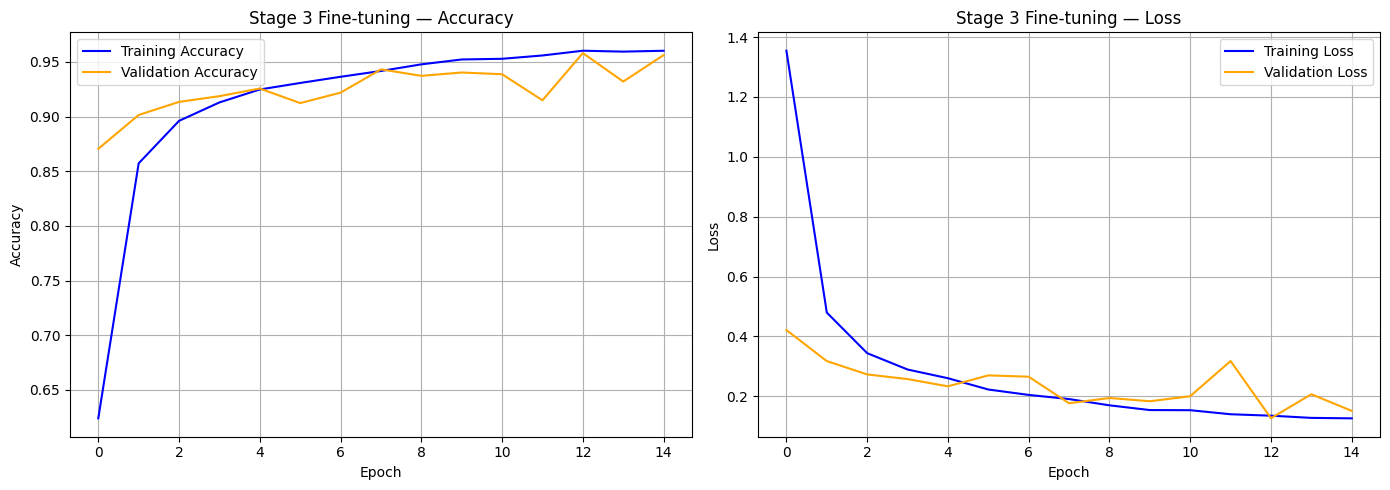

Plot saved!


In [12]:
import matplotlib.pyplot as plt

ft_acc = history_finetune.history['categorical_accuracy']
ft_val = history_finetune.history['val_categorical_accuracy']
ft_loss = history_finetune.history['loss']
ft_val_loss = history_finetune.history['val_loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(ft_acc, label='Training Accuracy', color='blue')
ax1.plot(ft_val, label='Validation Accuracy', color='orange')
ax1.set_title('Stage 3 Fine-tuning — Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(ft_loss, label='Training Loss', color='blue')
ax2.plot(ft_val_loss, label='Validation Loss', color='orange')
ax2.set_title('Stage 3 Fine-tuning — Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('stage3_finetune_results.png')
plt.show()
print("Plot saved!")

In [ ]:
model = k.Sequential([
    # Block 1 — 32 filters, your decision
    k.layers.Conv2D(32, (3,3), padding='same', input_shape=(IMG_SIZE, IMG_SIZE, 3)),
    k.layers.BatchNormalization(),
    k.layers.Activation('relu'),
    k.layers.MaxPooling2D(2,2),

    # Block 2 — 64 filters, your decision
    k.layers.Conv2D(64, (3,3), padding='same'),
    k.layers.BatchNormalization(),
    k.layers.Activation('relu'),
    k.layers.MaxPooling2D(2,2),

    # Block 3 — 128 filters, your decision
    k.layers.Conv2D(128, (3,3), padding='same'),
    k.layers.BatchNormalization(),
    k.layers.Activation('relu'),
    k.layers.MaxPooling2D(2,2),

    # Flatten and classify
    k.layers.Flatten(),
    k.layers.Dropout(0.25),          # your decision
    k.layers.Dense(256, activation='relu'),  # your decision
    k.layers.Dropout(0.5),           # your decision
    k.layers.Dense(num_classes, activation='softmax')
])

# Compile — same decisions as Stage 1
model.compile(
    optimizer=k.optimizers.Adam(),
    loss=k.losses.CategoricalCrossentropy(),
    metrics=[k.metrics.CategoricalAccuracy()]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128, 128, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,492,774 (32.40 MB)

 Trainable params: 8,492,326 (32.40 MB)

 Non-trainable params: 448 (1.75 KB)

In [ ]:
history = model.fit(
    train_dataset,
    epochs=20,
    validation_data=test_dataset,
    class_weight=class_weight_dict
)

Epoch 1/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 59s 36ms/step - categorical_accuracy: 0.0578 - loss: 3.6919 - val_categorical_accuracy: 0.0655 - val_loss: 3.4645
Epoch 2/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 47s 34ms/step - categorical_accuracy: 0.0654 - loss: 3.5170 - val_categorical_accuracy: 0.0630 - val_loss: 3.6670
Epoch 3/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - categorical_accuracy: 0.0809 - loss: 3.4533 - val_categorical_accuracy: 0.1350 - val_loss: 3.3764
Epoch 4/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 42s 31ms/step - categorical_accuracy: 0.1081 - loss: 3.3761 - val_categorical_accuracy: 0.1572 - val_loss: 3.2333
Epoch 5/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 83s 32ms/step - categorical_accuracy: 0.1076 - loss: 3.3235 - val_categorical_accuracy: 0.1372 - val_loss: 3.4333
Epoch 6/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 43s 31ms/step - categorical_accuracy: 0.1008 - loss: 3.3134 - val_categorical_accuracy: 0.0984 - val_loss: 3.5982
Epoch 7/20
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 43s 32ms/step - catego

In [ ]:
from google.colab import files
model.save('plant_disease_stage2_partial.h5')
files.download('plant_disease_stage2_partial.h5')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
history2 = model.fit(
    train_dataset,
    epochs=30,
    validation_data=test_dataset,
    class_weight=class_weight_dict
)

Epoch 1/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - categorical_accuracy: 0.3813 - loss: 2.0728 - val_categorical_accuracy: 0.6907 - val_loss: 1.1561
Epoch 2/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - categorical_accuracy: 0.4018 - loss: 1.9799 - val_categorical_accuracy: 0.6086 - val_loss: 1.5149
Epoch 3/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 40s 30ms/step - categorical_accuracy: 0.4228 - loss: 1.9033 - val_categorical_accuracy: 0.6789 - val_loss: 1.1518
Epoch 4/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - categorical_accuracy: 0.4472 - loss: 1.8101 - val_categorical_accuracy: 0.7546 - val_loss: 0.9895
Epoch 5/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - categorical_accuracy: 0.4623 - loss: 1.7498 - val_categorical_accuracy: 0.5346 - val_loss: 2.6206
Epoch 6/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 45s 33ms/step - categorical_accuracy: 0.4809 - loss: 1.6837 - val_categorical_accuracy: 0.7933 - val_loss: 0.8518
Epoch 7/30
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 41s 30ms/step - catego

In [ ]:
from google.colab import files
model.save('plant_disease_stage2.h5')
files.download('plant_disease_stage2.h5')
print("Stage 2 model saved!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Stage 2 model saved!


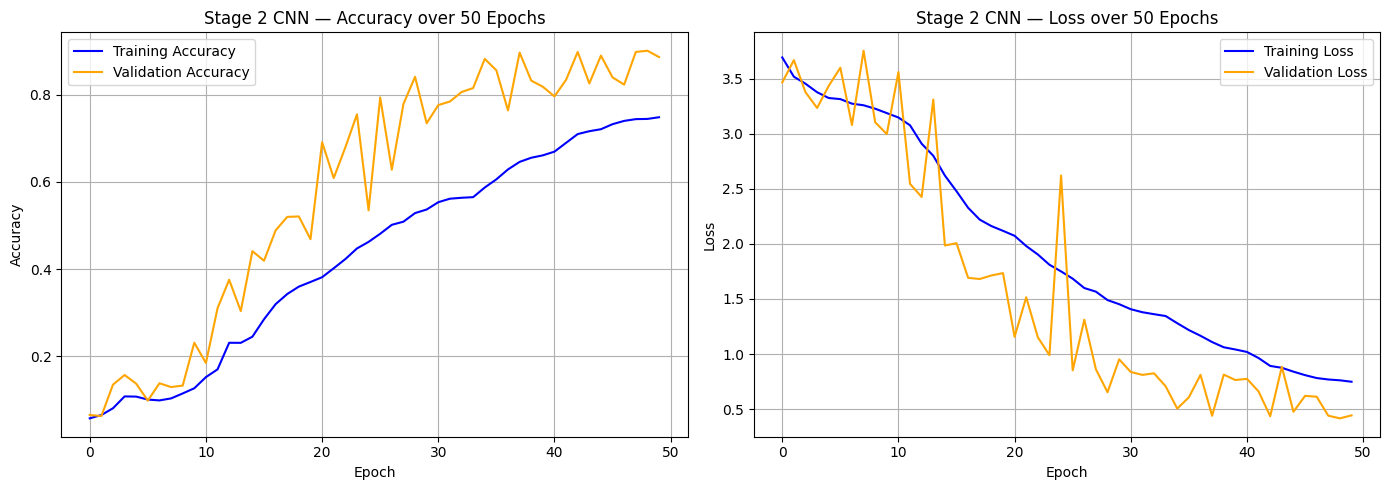

Stage 2 plot saved!


In [ ]:
import matplotlib.pyplot as plt

all_val_acc = history.history['val_categorical_accuracy'] + history2.history['val_categorical_accuracy']
all_train_acc = history.history['categorical_accuracy'] + history2.history['categorical_accuracy']
all_val_loss = history.history['val_loss'] + history2.history['val_loss']
all_train_loss = history.history['loss'] + history2.history['loss']

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(all_train_acc, label='Training Accuracy', color='blue')
ax1.plot(all_val_acc, label='Validation Accuracy', color='orange')
ax1.set_title('Stage 2 CNN — Accuracy over 50 Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(all_train_loss, label='Training Loss', color='blue')
ax2.plot(all_val_loss, label='Validation Loss', color='orange')
ax2.set_title('Stage 2 CNN — Loss over 50 Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('stage2_results.png')
plt.show()
print("Stage 2 plot saved!")

Model saved!


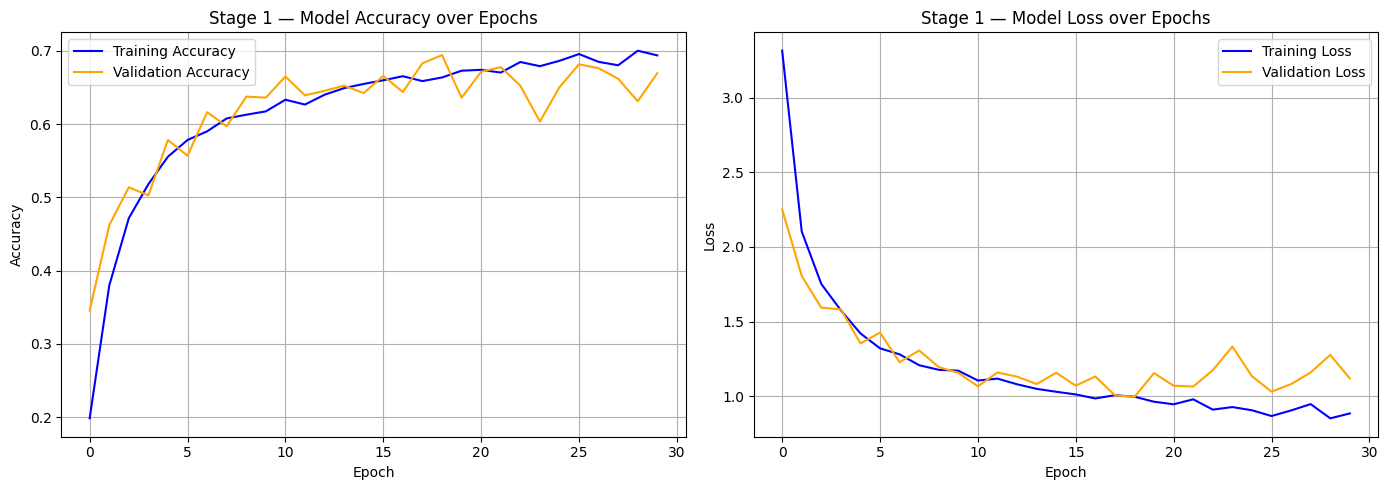

Plot saved!


In [ ]:
import matplotlib.pyplot as plt

# Save the model
model.save('plant_disease_stage1.h5')
print("Model saved!")

# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
ax1.plot(history.history['categorical_accuracy'], label='Training Accuracy', color='blue')
ax1.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy', color='orange')
ax1.set_title('Stage 1 — Model Accuracy over Epochs')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

# Loss plot
ax2.plot(history.history['loss'], label='Training Loss', color='blue')
ax2.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax2.set_title('Stage 1 — Model Loss over Epochs')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.savefig('stage1_results.png')
plt.show()
print("Plot saved!")

In [ ]:
from google.colab import files

model.save('plant_disease_stage1.h5')
files.download('plant_disease_stage1.h5')
print("Downloading model to your computer!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>